# Train Model Workflow

This notebook mirrors `train_model.py`, organized into logical steps.

## 1. Imports

In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier
import joblib

## 2. Load And Prepare Dataset

In [118]:
# Load dataset
df = pd.read_csv('cleaned_dataset.csv')
df = df.sort_values(by='game_date')  # Sort by date

player_cols = ["double_digit_scorers", 'top_points_avg', 'top_points_position', 'top_player_last_5_avg',
               'top_pra_avg', 'one_player_reliance', 'reliance_ranking', 'double_digit_scorers_ranking']

non_int_cols = ['opponent_team_uid_home', 'opponent_team_slug_home', 'opponent_team_short_display_name_home', 'opponent_team_uid_away', 'opponent_team_slug_away', 'opponent_team_short_display_name_away']

df.drop(columns=non_int_cols, inplace=True)

# Drop rank, pct, and unnecessary rate columns
df.drop(columns=[col for col in df.columns if 'rank' in col.lower() and col not in player_cols], inplace=True)
df.drop(columns=[col for col in df.columns if 'pct' in col.lower()], inplace=True)
df.drop(columns=[col for col in df.columns if 'rate' in col.lower() and not any(x in col.lower() for x in ['turnover_rate', 'offensive_rebound_rate', 'free_throw_rate'])], inplace=True)

In [ ]:
print("Pre: Number of nulls per column in df (ordered by highest nulls first):")
null_counts = df.isnull().sum().sort_values(ascending=False)
for col, count in null_counts.items():
    print(f"{col}: {count}")

df.fillna(-100, inplace=True)

print("Post: Number of nulls per column in df (ordered by highest nulls first):")
null_counts = df.isnull().sum().sort_values(ascending=False)
for col, count in null_counts.items():
    print(f"{col}: {count}")

Pre: Number of nulls per column in df (ordered by highest nulls first):
blown_lead_rolling_stdev_10_diff: 46750
blown_lead_rolling_mean_10_diff: 46750
margin_of_victory_rolling_mean_10_diff: 46750
margin_of_victory_rolling_stdev_10_diff: 46750
clutch_win_rolling_stdev_10_diff: 46750
clutch_win_rolling_mean_10_diff: 46750
clutch_loss_rolling_stdev_10_diff: 46750
clutch_loss_rolling_mean_10_diff: 46750
competitive_game_rolling_stdev_10_diff: 46750
competitive_game_rolling_mean_10_diff: 46750
blowout_win_rolling_mean_10_diff: 46750
blowout_win_rolling_stdev_10_diff: 46750
blowout_loss_rolling_stdev_10_diff: 46750
blowout_loss_rolling_mean_10_diff: 46750
defensive_efficiency_rolling_stdev_10_diff: 46750
points_rolling_mean_10_diff: 46750
turnover_rate_rolling_mean_10_diff: 46750
turnover_rate_rolling_stdev_10_diff: 46750
offensive_rebound_rate_rolling_mean_10_diff: 46750
offensive_rebound_rate_rolling_stdev_10_diff: 46750
free_throw_rate_rolling_mean_10_diff: 46750
points_rolling_stdev_10_

## 3. Train/Test Split And Shared Config

In [120]:
# Split train/test based on date
split_date = '2024-11-01'
train_df = df[df['game_date'] <= split_date].copy()
test_df = df[df['game_date'] > split_date].copy()

excluded_columns = ['away_games_played_diff','away_win_percentage_diff','Unnamed: 0', 'game_id', 'game_date', 'home_team', 'home_color', 'away_team', 'away_color', 'target', 'wins_diff', 'losses_diff', 'is_non_conference_game_diff', 'away_wins_diff','away_losses_diff','non_conf_losses_diff','non_conf_wins_diff','non_conf_win_percentage_diff','opponent_win_loss_percentage_diff','non_conference_win_loss_percentage_diff']

In [121]:
# save a subset where home_team is 'Kentucky' 
kentucky_subset = df[df['home_team'] == 'Kentucky'].copy()
kentucky_subset = kentucky_subset.drop(columns=excluded_columns)
kentucky_subset.to_csv('kentucky_subset.csv', index=False)


In [125]:
train_df.tail(10)

,Unnamed: 0,game_id,season_type,game_date,home_team,home_color,target,opponent_short_conference_name_home,away_team,away_color,...,non_conf_win_percentage_diff,opponent_recent_win_loss_5_diff,opponent_recent_win_loss_10_diff,opponent_recent_win_loss_15_diff,momentum_5_diff,momentum_10_diff,momentum_15_diff,weighted_momentum_5_diff,weighted_momentum_10_diff,weighted_momentum_15_diff
106570,6211,401522190,3,2023-03-25,Gonzaga,041e42,0,Amer,UConn,0c2340,...,0,-0.078375,-0.074993,-0.070472,0.2,0.1,0.133333,-0.082672,-0.122366,-0.095355
106569,6210,401522193,3,2023-03-25,Kansas State,3c0969,0,Amer,Florida Atlantic,00447c,...,0,0.173628,0.160953,0.142484,-0.4,-0.3,-0.266667,0.177975,0.261268,0.213598
106572,6213,401522196,3,2023-03-26,Texas,c15d26,0,ACC,Miami,004325,...,0,0.029642,0.038787,0.019441,0.2,0.0,-0.066667,0.641080,0.488162,0.427555
106571,6212,401522199,3,2023-03-26,San Diego State,BF2C37,1,BE,Creighton,13299e,...,0,-0.169452,-0.166690,-0.157945,0.2,0.2,0.133333,0.106105,0.101059,0.083711
106573,6214,401526930,3,2023-03-28,North Texas,ffffff,1,B10,Wisconsin,c4012f,...,0,-0.239183,-0.230867,-0.211157,0.0,0.2,0.333333,-0.415749,-0.253107,-0.171147
106574,6215,401526927,3,2023-03-28,UAB,054338,1,GWC,Utah Valley,004812,...,0,0.022685,0.031833,0.039902,0.0,0.1,0.066667,0.108694,0.149132,0.137415
106575,6216,401526932,3,2023-03-30,North Texas,ffffff,1,Amer,UAB,054338,...,0,-0.051514,-0.062967,-0.073625,0.0,-0.1,0.000000,-0.041211,-0.130732,-0.063808
106576,6217,401522200,3,2023-04-01,San Diego State,BF2C37,1,Amer,Florida Atlantic,00447c,...,0,0.090922,0.091770,0.101645,0.0,-0.1,0.000000,-0.366151,-0.407059,-0.329216
106577,6218,401522201,3,2023-04-01,UConn,0c2340,1,ACC,Miami,004325,...,0,0.023392,0.036378,0.037701,0.0,0.1,0.000000,0.429672,0.516794,0.469864
106578,6219,401522202,3,2023-04-03,UConn,0c2340,1,MWC,San Diego State,BF2C37,...,0,0.057236,0.048893,0.051005,0.0,0.0,-0.066667,0.442764,0.389874,0.348382


## 4. Train Winner Prediction Model

In [ ]:
# Winner prediction model
tournament_games = train_df[train_df['season_type'] == 3].copy()
train_df_weighted = pd.concat([train_df] + [tournament_games.copy() for _ in range(4)], ignore_index=True)  # 5x weight

# Add these values to excluded_columns opponent_short_conference_name_home, opponent_short_conference_name_away
excluded_columns.extend(['opponent_short_conference_name_home', 'opponent_short_conference_name_away'])
X_train = train_df_weighted.drop(columns=excluded_columns)
y_train = train_df_weighted['target'].astype(int)
print(X_train.columns.to_list())

X_test = test_df.drop(columns=excluded_columns)
y_test = test_df['target'].astype(int)

winner_params = dict(
    objective="binary",
    metric="binary_logloss",
    boosting_type="gbdt",
    learning_rate=0.02,
    n_estimators=4000,
    max_depth=6,
    num_leaves=63,
    min_child_samples=60,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    lambda_l1=0.5,
    lambda_l2=5.0,
    min_gain_to_split=0.01,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)


model_winner = LGBMClassifier(**winner_params)

print("\nTraining winner prediction model...")
model_winner.fit(X_train, y_train)

['season_type', 'net_rating_diff', 'recent_net_rating_diff', 'points_per_game_diff', 'points_stdev_diff', 'assists_per_game_diff', 'assists_stdev_diff', 'blocks_per_game_diff', 'blocks_stdev_diff', 'defensive_rebounds_per_game_diff', 'defensive_rebounds_stdev_diff', 'field_goals_made_per_game_diff', 'field_goals_made_stdev_diff', 'field_goals_attempted_per_game_diff', 'field_goals_attempted_stdev_diff', 'flagrant_fouls_per_game_diff', 'flagrant_fouls_stdev_diff', 'fouls_per_game_diff', 'fouls_stdev_diff', 'free_throws_made_per_game_diff', 'free_throws_made_stdev_diff', 'free_throws_attempted_per_game_diff', 'free_throws_attempted_stdev_diff', 'offensive_rebounds_per_game_diff', 'offensive_rebounds_stdev_diff', 'steals_per_game_diff', 'steals_stdev_diff', 'team_turnovers_per_game_diff', 'team_turnovers_stdev_diff', 'technical_fouls_per_game_diff', 'technical_fouls_stdev_diff', 'three_point_field_goals_made_per_game_diff', 'three_point_field_goals_made_stdev_diff', 'three_point_field_goa

,boosting_type,'gbdt'
,num_leaves,255
,max_depth,6
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 5. Train Upset Prediction Model

In [ ]:
# Upset prediction model
tournament_df = train_df[train_df['season_type'] == 3].copy()
upset_games = tournament_df[(tournament_df['net_rating_diff'] <= -20) & (tournament_df['target'] == 1)].copy()
upset_df = pd.concat([tournament_df] + [upset_games.copy() for _ in range(4)], ignore_index=True)  # 5x weight

X_train_upset = upset_df.drop(columns=excluded_columns)
y_train_upset = upset_df['target'].astype(int)

upset_params = dict(
    objective="binary",
    metric="aucpr",   # better for rare-event focus
    boosting_type="gbdt",
    learning_rate=0.015,
    n_estimators=5000,
    max_depth=5,
    num_leaves=31,
    min_child_samples=80,
    feature_fraction=0.75,
    bagging_fraction=0.75,
    bagging_freq=1,
    lambda_l1=0.5,
    lambda_l2=8.0,
    min_gain_to_split=0.02,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)


model_upset = LGBMClassifier(**upset_params)

print("\nTraining upset prediction model...")
model_upset.fit(X_train_upset, y_train_upset)


Training upset prediction model...


,boosting_type,'gbdt'
,num_leaves,127
,max_depth,4
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 6. Save Models

In [135]:
joblib.dump(model_winner, 'models/lgbm_winner_model.joblib')
joblib.dump(model_upset, 'models/lgbm_upset_model.joblib')

['models/lgbm_upset_model.joblib']

## 7. Define Evaluation Helper

In [136]:
def evaluate_thresholds(model, X_test, y_test, model_name):
    thresholds = np.linspace(0.1, 0.8, 10)  # Test thresholds from 0.1 to 0.8
    metrics = []

    # Create mask for actual 0 values (away team wins)
    actual_zero_mask = (y_test == 0)

    for thresh in thresholds:
        # Get predictions based on threshold
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred_thresh = (y_pred_proba > thresh).astype(int)

        # Calculate standard metrics
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)
        accuracy = accuracy_score(y_test, y_pred_thresh)

        # Calculate accuracy for cases where the actual value is 0
        # This shows how well the model identifies games where away team wins
        if np.sum(actual_zero_mask) > 0:
            actual_zero_accuracy = accuracy_score(
                y_test[actual_zero_mask],
                y_pred_thresh[actual_zero_mask]
            )
        else:
            actual_zero_accuracy = 0

        metrics.append([thresh, precision, recall, f1, accuracy, actual_zero_accuracy])

    # Convert to DataFrame
    metrics_df = pd.DataFrame(
        metrics,
        columns=["Threshold", "Precision", "Recall", "F1 Score", "Accuracy", "Accuracy_Actual_0"]
    )

    # Plot metrics
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=metrics_df, x="Threshold", y="Precision", label="Precision", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Recall", label="Recall", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="F1 Score", label="F1 Score", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy", label="Accuracy", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy_Actual_0",
                 label="Accuracy When Away Team Wins", marker="o", linestyle="--", color="purple")

    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Optimization - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print count of actual away team wins
    print(f"Number of actual away team wins in test set: {np.sum(actual_zero_mask)}")

    # Find and return the best threshold based on F1 Score
    best_threshold = metrics_df.loc[metrics_df["F1 Score"].idxmax(), "Threshold"]
    return best_threshold

## 8. Evaluate Thresholds

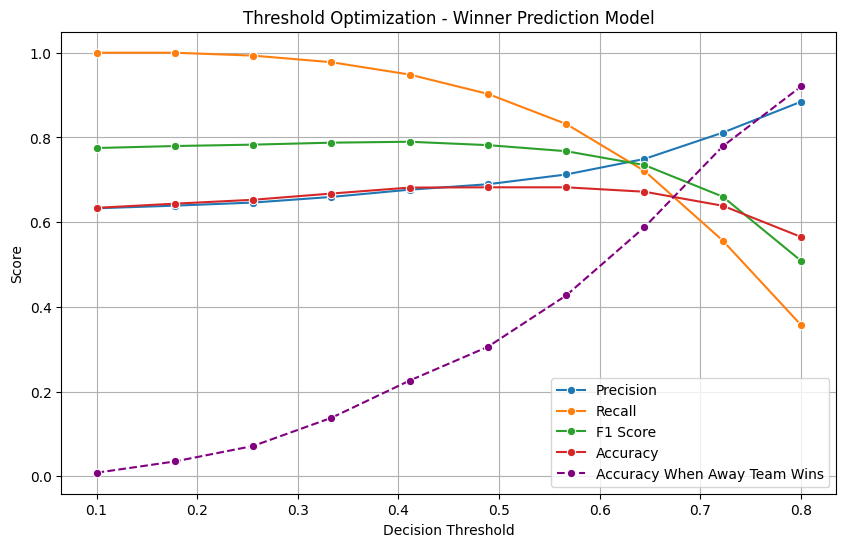

Number of actual away team wins in test set: 602


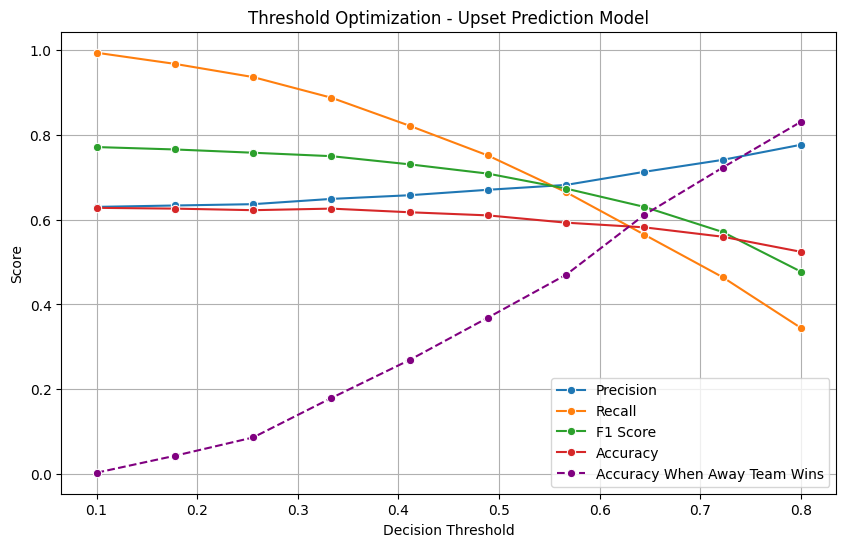

Number of actual away team wins in test set: 602

Optimal Decision Threshold (Winner Model): 0.41
Optimal Decision Threshold (Upset Model): 0.10


In [137]:
best_thresh_winner = evaluate_thresholds(model_winner, X_test, y_test, "Winner Prediction Model")
best_thresh_upset = evaluate_thresholds(model_upset, X_test, y_test, "Upset Prediction Model")

print(f"\nOptimal Decision Threshold (Winner Model): {best_thresh_winner:.2f}")
print(f"Optimal Decision Threshold (Upset Model): {best_thresh_upset:.2f}")

## 9. Define Feature Importance Helper

In [138]:
def plot_feature_importance(model, X_train, model_name):
    feature_importances = model.feature_importances_
    feature_names = X_train.columns

    feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    top_20_features = feat_importance_df.sort_values(by="Importance", ascending=False).head(30)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title(f"Top 20 Features - {model_name}")
    plt.show()

## 10. Plot Feature Importances

C:\Users\johns\AppData\Local\Temp\ipykernel_8696\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


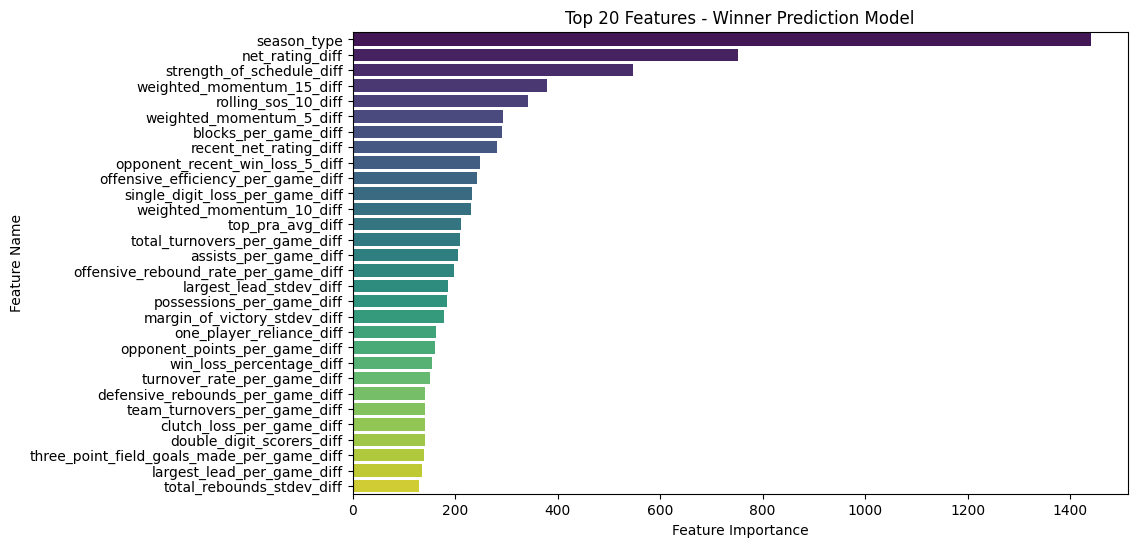

C:\Users\johns\AppData\Local\Temp\ipykernel_8696\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


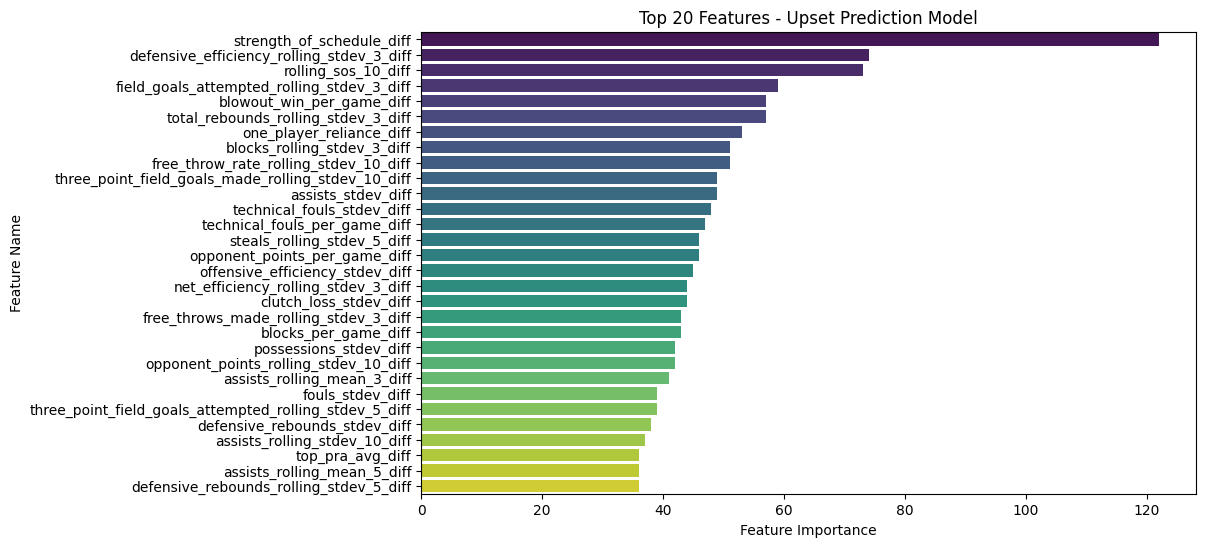

In [139]:
plot_feature_importance(model_winner, X_train, "Winner Prediction Model")
plot_feature_importance(model_upset, X_train_upset, "Upset Prediction Model")